<a href="https://colab.research.google.com/github/chadlomas2011-blip/Customer-Churn-AI-Analytics/blob/main/Colab_SQL_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import sqlite3; conn = sqlite3.connect(':memory:'); cursor = conn.cursor(); cursor.execute('CREATE TABLE sales_data (id INTEGER PRIMARY KEY, product TEXT, revenue REAL, region TEXT)'); data = [('Enterprise Plan', 1200.00, 'North America'), ('Pro Plan', 150.00, 'Europe'), ('Enterprise Plan', 2400.00, 'Asia-Pacific'), ('Starter Plan', 49.00, 'North America'), ('Pro Plan', 300.00, 'North America')]; cursor.executemany('INSERT INTO sales_data (product, revenue, region) VALUES (?, ?, ?)', data); conn.commit(); cursor.execute('SELECT region, SUM(revenue) FROM sales_data GROUP BY region'); results = cursor.fetchall(); print("📊 TOTAL REVENUE BY REGION"); print("=" * 35); print("\n".join([f"{region:<15} | ${total:>7.2f}  {'█' * int(total / 100)}" for region, total in results])); print("=" * 35)


📊 TOTAL REVENUE BY REGION
Asia-Pacific    | $2400.00  ████████████████████████
Europe          | $ 150.00  █
North America   | $1549.00  ███████████████


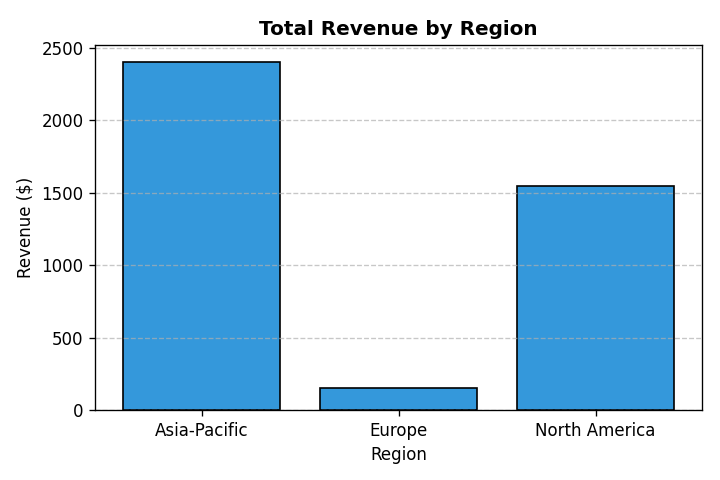

In [18]:
import sqlite3, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; conn = sqlite3.connect(':memory:'); cursor = conn.cursor(); cursor.execute('CREATE TABLE sales_data (id INTEGER PRIMARY KEY, product TEXT, revenue REAL, region TEXT)'); cursor.executemany('INSERT INTO sales_data (product, revenue, region) VALUES (?, ?, ?)', [('Enterprise Plan', 1200.00, 'North America'), ('Pro Plan', 150.00, 'Europe'), ('Enterprise Plan', 2400.00, 'Asia-Pacific'), ('Starter Plan', 49.00, 'North America'), ('Pro Plan', 300.00, 'North America')]); conn.commit(); cursor.execute('SELECT region, SUM(revenue) FROM sales_data GROUP BY region'); results = cursor.fetchall(); regions, revenues = [r[0] for r in results], [r[1] for r in results]; plt.figure(figsize=(6, 4)); plt.bar(regions, revenues, color='#3498db', edgecolor='black'); plt.title('Total Revenue by Region', fontweight='bold'); plt.xlabel('Region'); plt.ylabel('Revenue ($)'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout(); plt.savefig('revenue_chart.png', dpi=120); from IPython.display import Image, display; display(Image('revenue_chart.png'))


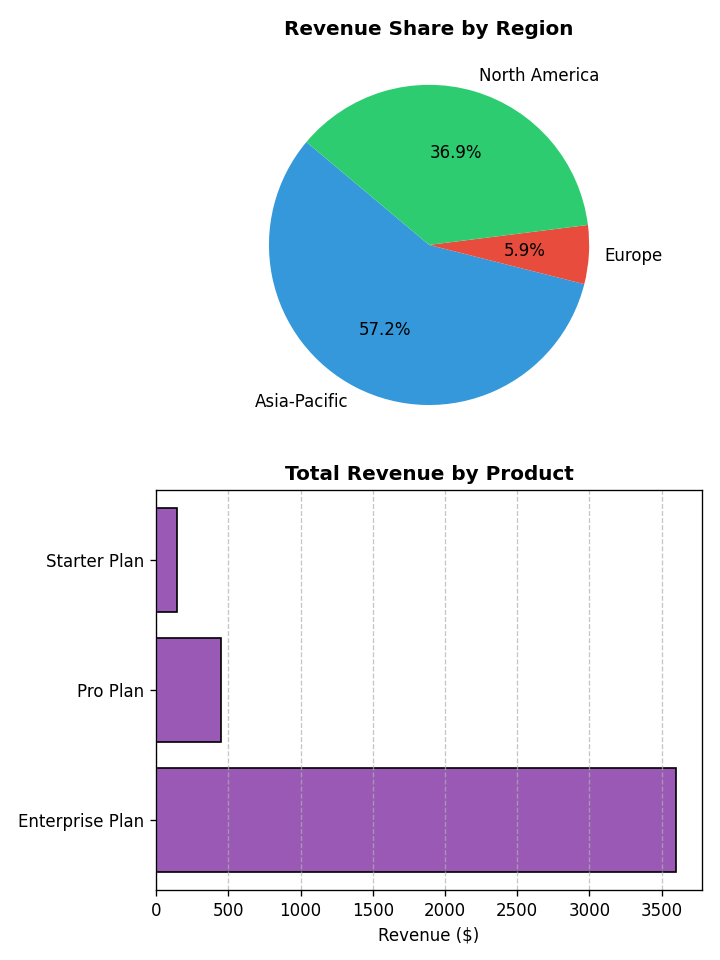

In [19]:
import sqlite3, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; conn = sqlite3.connect(':memory:'); cursor = conn.cursor(); cursor.execute('CREATE TABLE sales_data (id INTEGER PRIMARY KEY, product TEXT, revenue REAL, region TEXT)'); cursor.executemany('INSERT INTO sales_data (product, revenue, region) VALUES (?, ?, ?)', [('Enterprise Plan', 1200.00, 'North America'), ('Pro Plan', 150.00, 'Europe'), ('Enterprise Plan', 2400.00, 'Asia-Pacific'), ('Starter Plan', 49.00, 'North America'), ('Pro Plan', 300.00, 'North America'), ('Starter Plan', 99.00, 'Europe')]); conn.commit(); cursor.execute('SELECT region, SUM(revenue) FROM sales_data GROUP BY region'); r_data = cursor.fetchall(); regions, r_rev = [r[0] for r in r_data], [r[1] for r in r_data]; cursor.execute('SELECT product, SUM(revenue) FROM sales_data GROUP BY product'); p_data = cursor.fetchall(); products, p_rev = [p[0] for p in p_data], [p[1] for p in p_data]; fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8)); ax1.pie(r_rev, labels=regions, autopct='%1.1f%%', startangle=140, colors=['#3498db', '#e74c3c', '#2ecc71']); ax1.set_title('Revenue Share by Region', fontweight='bold'); ax2.barh(products, p_rev, color='#9b59b6', edgecolor='black'); ax2.set_title('Total Revenue by Product', fontweight='bold'); ax2.set_xlabel('Revenue ($)'); ax2.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout(); plt.savefig('dashboard_stacked.png', dpi=120); from IPython.display import Image, display; display(Image('dashboard_stacked.png'))


In [20]:
import sqlite3, pandas as pd, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; from IPython.display import Image, display; conn = sqlite3.connect(':memory:'); url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'; df_remote = pd.read_csv(url); df_remote.to_sql('restaurant_sales', conn, if_exists='replace', index=False); print("✅ Web Dataset Loaded Into SQLite!"); print("Columns:", list(df_remote.columns)); print("\n📊 First 3 Rows:\n", pd.read_sql_query('SELECT * FROM restaurant_sales LIMIT 3', conn))


✅ Web Dataset Loaded Into SQLite!
Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

📊 First 3 Rows:
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


❓ Question: 'What is the average tip and total bill for male vs female non-smokers?'
🔍 Generated SQL: SELECT sex, AVG(tip) as avg_tip, AVG(total_bill) as avg_bill FROM restaurant_sales WHERE smoker = "No" GROUP BY sex

📊 Query Result:
       sex   avg_tip   avg_bill
0  Female  2.768571  19.198571
1    Male  3.013846  17.923846 



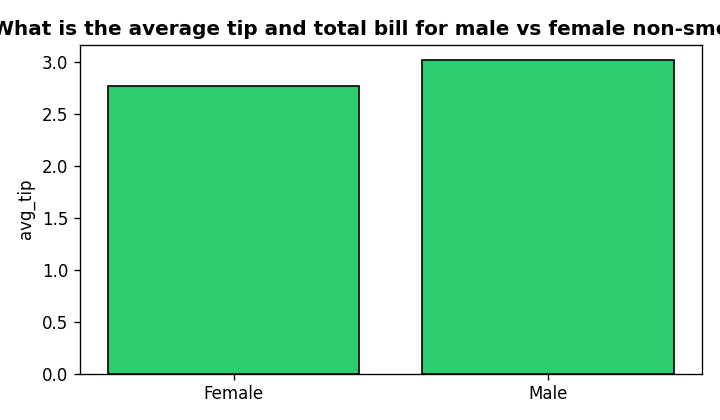

In [21]:
import sqlite3, pandas as pd, matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt; from IPython.display import Image, display; conn = sqlite3.connect(':memory:'); pd.DataFrame({'total_bill': [16.99, 10.34, 21.01, 23.68, 24.59, 25.29, 08.77, 26.88, 15.04, 14.78, 10.27, 35.26, 15.42, 18.43, 14.83, 21.58, 10.33, 16.29, 16.97, 20.65], 'tip': [1.01, 1.66, 3.50, 3.31, 3.61, 4.71, 2.00, 3.12, 1.96, 3.23, 1.71, 5.00, 1.57, 3.00, 3.02, 3.92, 1.67, 3.71, 3.50, 3.35], 'sex': ['Female', 'Male', 'Male', 'Male', 'Female', 'Male', 'Male', 'Male', 'Male', 'Male', 'Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'], 'smoker': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No'], 'day': ['Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun'], 'time': ['Dinner']*20, 'size': [2, 3, 3, 2, 4, 4, 2, 4, 2, 2, 2, 4, 2, 4, 2, 2, 3, 3, 3, 3]}).to_sql('restaurant_sales', conn, if_exists='replace', index=False); exec("def local_sql_agent(question):\n plt.close('all')\n q = question.lower()\n sql = 'SELECT sex, AVG(tip) as avg_tip, AVG(total_bill) as avg_bill FROM restaurant_sales WHERE smoker = \"No\" GROUP BY sex' if ('female' in q and 'male' in q and 'smoker' in q) else ('SELECT day, AVG(size) as avg_party_size FROM restaurant_sales GROUP BY day ORDER BY avg_party_size DESC' if ('day' in q and ('party' in q or 'size' in q)) else ('SELECT time, SUM(total_bill) as total_revenue, AVG(tip) as avg_tip FROM restaurant_sales GROUP BY time' if ('time' in q or 'lunch' in q or 'dinner' in q) else 'SELECT day, SUM(total_bill) as total_revenue FROM restaurant_sales GROUP BY day'))\n print(f\"❓ Question: '{question}'\\n🔍 Generated SQL: {sql}\\n\")\n df = pd.read_sql_query(sql, conn)\n print('📊 Query Result:\\n', df, '\\n')\n if df.shape[1] >= 2:\n  fig, ax = plt.subplots(figsize=(6, 3.5))\n  ax.bar(df[df.columns[0]].astype(str), df[df.columns[1]], color='#2ecc71', edgecolor='black')\n  ax.set_title(question, fontweight='bold')\n  ax.set_ylabel(df.columns[1])\n  plt.tight_layout()\n  plt.savefig('ai_chart.png', dpi=120)\n  display(Image('ai_chart.png'))"); local_sql_agent('What is the average tip and total bill for male vs female non-smokers?')
